## Weather version 2.0 (version 1 died in the sandbox)
Cathal Redmond 14 Dec 2025 (ho ho ho)

In [46]:
# define imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime



In [47]:
# Define the location of the file. 
# I will attempt to load in the larger hourly file correctly first and see if i can make it to be small enough to upload to the github location. 

url = "https://cli.fusio.net/cli/climate_data/webdata/hly4935.csv"

# define the columns to use as a list 
col_list = [0,4,12,14]

#Read the data from the URL and assign it into a dataframe "df"
df = pd.read_csv(url, 
                 usecols = col_list, 
                 skiprows = 24, 
                 names = ('date_and_time','temperature','windspeed','winddir')
                 )

# display information / details about the dataframe 
df.info()

# Show some of the data to check its form
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257154 entries, 0 to 257153
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date_and_time  257154 non-null  object 
 1   temperature    257154 non-null  float64
 2   windspeed      257154 non-null  object 
 3   winddir        257154 non-null  object 
dtypes: float64(1), object(3)
memory usage: 7.8+ MB


C:\Users\catha\AppData\Local\Temp\ipykernel_15980\383256177.py:10: DtypeWarning: Columns (12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url,


,date_and_time,temperature,windspeed,winddir
0,10-apr-1996 14:00,11.5,0,0
1,31-jul-1996 08:00,11.5,0,0
2,31-jul-1996 09:00,11.6,0,0


In [53]:
# format the data into desired types
df['date_and_time'] = pd.to_datetime(df['date_and_time'],format='mixed')
df['date'] = df['date_and_time'].dt.strftime('%Y %m %d')
df['time'] = df['date_and_time'].dt.strftime('%H:%M')
df['month'] = df['date_and_time'].dt.strftime('%m')

print("Datetime data is of type: ",type(datetime))

# display information / details about the dataframe 
df.info()

# Show some of the data to check its form
df.head(3)


Datetime data is of type:  <class 'type'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257154 entries, 0 to 257153
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date_and_time  257154 non-null  datetime64[ns]
 1   temperature    257154 non-null  float64       
 2   windspeed      257154 non-null  object        
 3   winddir        257154 non-null  object        
 4   date           257154 non-null  object        
 5   time           257154 non-null  object        
 6   month          257154 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 13.7+ MB


,date_and_time,temperature,windspeed,winddir,date,time,month
0,1996-04-10 14:00:00,11.5,0,0,1996 04 10,14:00,04
1,1996-07-31 08:00:00,11.5,0,0,1996 07 31,08:00,07
2,1996-07-31 09:00:00,11.6,0,0,1996 07 31,09:00,07


<Axes: xlabel='date_and_time'>

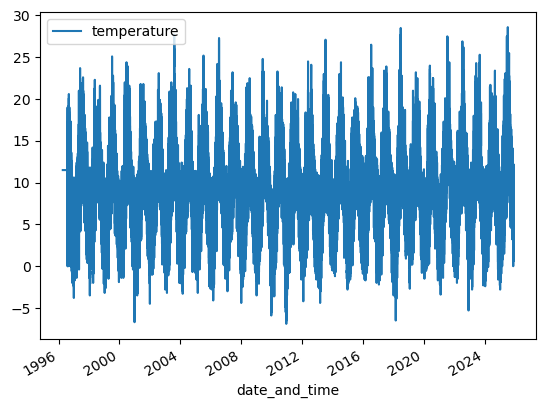

In [49]:
# Create a plot showing the temperature data over time

df.plot('date_and_time','temperature')

In [50]:
# calculate the mean temperature for each day
# we will use the pivot table method to achieve this task

MeanTemp = pd.pivot_table(df,'temperature', 'date', aggfunc='mean')
print(type(MeanTemp)) # shows the dataframe
MeanTemp.head(3)



<class 'pandas.core.frame.DataFrame'>


,temperature
date,
1996 04 10,11.500000
1996 07 31,12.650000
1996 08 01,11.666667


<Axes: title={'center': 'Mean Temperature by Date'}, xlabel='date'>

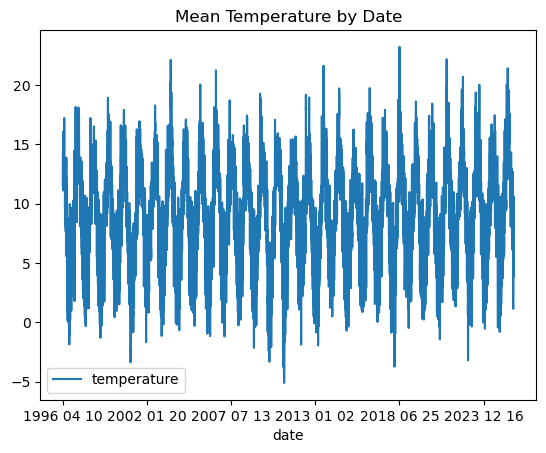

In [52]:
# plot the mean temperature graph also
MeanTemp.plot(kind = 'line',title = 'Mean Temperature by Date')

In [55]:
# calcuate the average temperature for each month 
# (I am assuming this is the average temperature per month for all years pooled)

MonthTemp = pd.pivot_table(df,'temperature', 'month', aggfunc='mean')
print(type(MonthTemp)) # shows the dataframe
MonthTemp.head(3)

<class 'pandas.core.frame.DataFrame'>


,temperature
month,
01,4.328953
02,4.699166
03,5.679973


<function matplotlib.pyplot.show(close=None, block=None)>

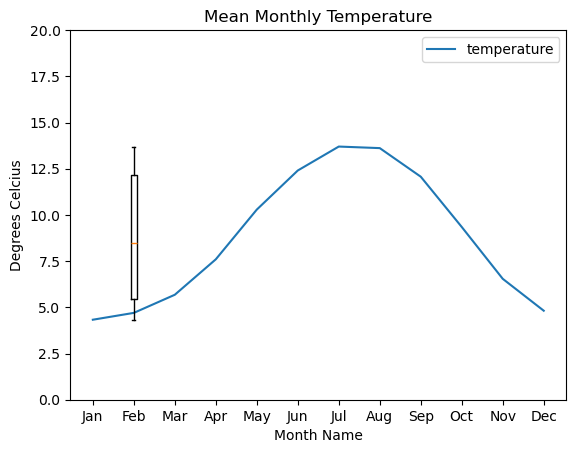

In [67]:
# plot the mean temperature per monyh graph
MonthTemp.plot(kind = 'line',title = 'Mean Monthly Temperature')

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.boxplot(MonthTemp)
plt.title("Mean Monthly Temperature")
plt.xlabel("Month Name")
plt.ylabel("Degrees Celcius")
plt.ylim(0,20)
plt.xticks(np.arange(12), months)
plt.show

In [ ]:
# going for the big scores: Windspeed 


## End of code
Cathal Redmond 14 Dec 2025
